# Feature Selection in Image Analysis using Genetic Algorithms + SVM

---

## Problem Statement

Modern image analysis pipelines often extract **high-dimensional feature vectors** by combining multiple descriptors. This project uses a dataset with **4844 features** — a combination of:
- **HOG (Histogram of Oriented Gradients):** Captures edge/shape structure by computing gradient orientations in localized image patches.
- **LBP (Local Binary Patterns):** Captures texture information by thresholding pixel neighborhoods.

While combining descriptors improves representational power, it introduces the **curse of dimensionality**:
- Model training time increases dramatically
- Irrelevant/redundant features add noise and hurt generalization
- Memory and inference costs become prohibitive
- Overfitting risk increases, especially with limited data

## Approach

We use a **Genetic Algorithm (GA)** — a population-based metaheuristic inspired by biological evolution — to search the exponentially large feature subset space (2^8110 possible subsets).

Each **individual** in the GA population is a **binary chromosome** of length 8,110:
- `1` = feature selected
- `0` = feature excluded

A **Support Vector Machine (SVM)** acts as the fitness evaluator: a chromosome's quality is measured by the cross-validated accuracy of an SVM trained only on its selected features.

The fitness function balances **accuracy** vs **feature reduction**:

```
fitness = alpha * accuracy + beta * (1 - selected_ratio)
```

where `alpha=0.9` prioritizes accuracy and `beta=0.1` rewards smaller feature subsets.

---

**Goal:** Find a compact feature subset that matches or exceeds baseline SVM performance on all 8,110 features.

In [1]:
# ============================================================
# Cell 1: Import all required libraries and configure globals.
# Sets numpy random seed for full reproducibility.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import time

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from tqdm import tqdm

# ── Global settings ──────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# ── Output directory for saved figures ──────────────────────
os.makedirs('figures', exist_ok=True)

print("All imports successful.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Random seed set to: {RANDOM_SEED}")

All imports successful.
   NumPy  : 2.3.2
   Pandas : 2.3.2
   Random seed set to: 42


---
<a id='section2'></a>
## 2. Data Loading & Exploration

In [3]:
# ============================================================
# Cell 2: Load pre-extracted HOG+LBP feature arrays from disk.
# Prints shapes, number of classes, and class distribution.
# ============================================================

X = np.load('evolutionary-image-feature-selection-main/notebooks/XPCA_features.npy')
y = np.load('y_labels.npy')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Feature matrix shape  : {X.shape}  (samples , features)")
print(f"Label vector shape    : {y.shape}")
print(f"Total samples         : {X.shape[0]}")
print(f"Total features        : {X.shape[1]}")

# ── Class information ────────────────────────────────────────
unique_classes, class_counts = np.unique(y, return_counts=True)
n_classes = len(unique_classes)
print(f"\nNumber of classes     : {n_classes}")
print(f"Class labels          : {unique_classes}")
print("\nClass distribution:")
for cls, cnt in zip(unique_classes, class_counts):
    pct = cnt / len(y) * 100
    print(f"   Class {cls:>3}  →  {cnt:>5} samples  ({pct:.1f}%)")

# ── Feature statistics ───────────────────────────────────────
print(f"\nFeature value range   : [{X.min():.4f}, {X.max():.4f}]")
print(f"Feature mean          : {X.mean():.4f}")
print(f"Feature std           : {X.std():.4f}")

# ── Check for NaN / Inf ──────────────────────────────────────
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"\nNaN values            : {nan_count}")
print(f"Inf values            : {inf_count}")
if nan_count == 0 and inf_count == 0:
    print("Data is clean — no NaN or Inf values.")

FileNotFoundError: [Errno 2] No such file or directory: 'evolutionary-image-feature-selection-main/notebooks/XPCA_features.npy'

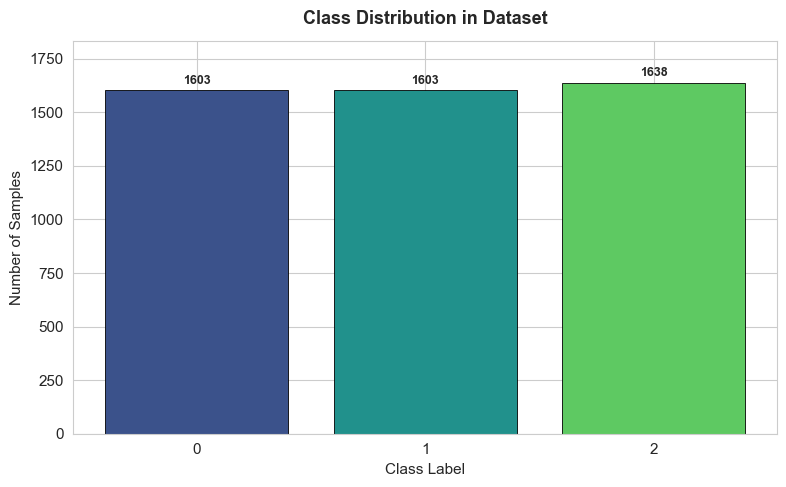

Figure saved : figures/class_distribution.png


In [ ]:
# ============================================================
# Cell 3: Visualise class distribution as a bar chart.
# ============================================================

fig, ax = plt.subplots(figsize=(max(8, n_classes * 0.7), 5))

colors = sns.color_palette('viridis', n_classes)
bars = ax.bar(unique_classes.astype(str), class_counts, color=colors, edgecolor='black', linewidth=0.6)

# Annotate bars with counts
for bar, cnt in zip(bars, class_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(class_counts) * 0.01,
        str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Class Distribution in Dataset', fontweight='bold', pad=12)
ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(class_counts) * 1.12)
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved : figures/class_distribution.png")

In [ ]:
# ============================================================
# Cell 4: Split data 80/20 train/test with stratification.
# Standardise features (fit on train, transform both splits).
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)


print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test samples      : {X_test.shape[0]}   ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Feature dimension : {X_train.shape[1]}")
print("\nTrain class counts:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls}: {cnt}")
print("\nTest class counts:")
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"   Class {cls}: {cnt}")
print("\nStandardisation applied (fit on train only).")

TRAIN / TEST SPLIT
Training samples  : 3875  (80.0%)
Test samples      : 969   (20.0%)
Feature dimension : 4844

Train class counts:
   Class 0: 1282
   Class 1: 1283
   Class 2: 1310

Test class counts:
   Class 0: 321
   Class 1: 320
   Class 2: 328

Standardisation applied (fit on train only).


---
<a id='section3'></a>
## 3. Baseline SVM (No Feature Selection)

In [ ]:
# ============================================================
# Cell 5: Train a baseline SVM on all 8110 features.
# Reports accuracy, F1 score, classification report, and
# confusion matrix.  This benchmark is used for comparison.
# ============================================================

print("Training baseline SVM on ALL features...")
t0 = time.time()

baseline_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
baseline_svm.fit(X_train, y_train)
y_pred_baseline = baseline_svm.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1       = f1_score(y_test, y_pred_baseline, average='weighted')
elapsed           = time.time() - t0

print("\n" + "=" * 50)
print("BASELINE SVM RESULTS")
print("=" * 50)
print(f"Features used         : {X_train.shape[1]}  (all features)")
print(f"Test Accuracy         : {baseline_accuracy:.4f}  ({baseline_accuracy*100:.2f}%)")
print(f"Weighted F1-Score     : {baseline_f1:.4f}")
print(f"Training time         : {elapsed:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Training baseline SVM on ALL features...

BASELINE SVM RESULTS
Features used         : 4844  (all features)
Test Accuracy         : 0.8297  (82.97%)
Weighted F1-Score     : 0.8282
Training time         : 86.6s

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       321
           1       0.81      0.72      0.76       320
           2       0.89      0.92      0.90       328

    accuracy                           0.83       969
   macro avg       0.83      0.83      0.83       969
weighted avg       0.83      0.83      0.83       969



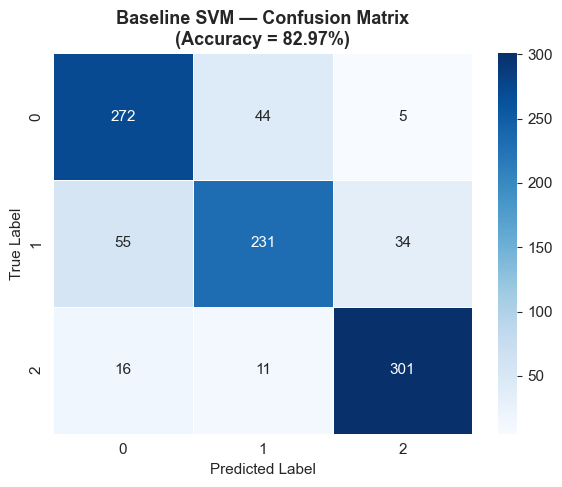

Figure saved → figures/baseline_confusion_matrix.png


In [ ]:
# ============================================================
# Cell 6: Plot the confusion matrix as a heatmap.
# ============================================================

cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Baseline SVM — Confusion Matrix\n(Accuracy = {baseline_accuracy*100:.2f}%)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('figures/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/baseline_confusion_matrix.png")

---
<a id='section4'></a>
## 4. GA Core Implementation

Each individual is a **binary vector of length 4844**: `1` = feature selected, `0` = not.  
Fitness balances **accuracy** (maximise) and **feature count** (minimise):

In [ ]:
# ============================================================
# Cell 7: GA hyper-parameters — defined once as constants.
# ============================================================

# ── GA hyper-parameters ──────────────────────────────────────
N_FEATURES        = X_train.shape[1]   # 8110
POPULATION_SIZE   = 30
N_GENERATIONS     = 30
INIT_FEAT_PROB    = 0.3    # probability a feature is set to 1 at init
CROSSOVER_RATE    = 0.8
DEFAULT_MUT_RATE  = 0.01   # per-bit mutation probability
ALPHA             = 0.9    # fitness weight: accuracy vs compactness
MIN_FEATURES      = 10     # minimum selected features enforced always
ELITISM_K         = 2      # number of elite individuals carried forward
TOURNAMENT_SIZE   = 3
UNIFORM_SWAP_PROB = 0.5

print("=" * 50)
print("GA HYPER-PARAMETERS")
print("=" * 50)
params = {
    'Total features'       : N_FEATURES,
    'Population size'      : POPULATION_SIZE,
    'Generations'          : N_GENERATIONS,
    'Init feature prob'    : INIT_FEAT_PROB,
    'Crossover rate'       : CROSSOVER_RATE,
    'Default mutation rate': DEFAULT_MUT_RATE,
    'Alpha (fitness)'      : ALPHA,
    'Min features enforced': MIN_FEATURES,
    'Elitism k'            : ELITISM_K,
    'Tournament size'      : TOURNAMENT_SIZE,
}
for k, v in params.items():
    print(f"   {k:<28}: {v}")

GA HYPER-PARAMETERS
   Total features              : 4844
   Population size             : 30
   Generations                 : 30
   Init feature prob           : 0.3
   Crossover rate              : 0.8
   Default mutation rate       : 0.01
   Alpha (fitness)             : 0.9
   Min features enforced       : 10
   Elitism k                   : 2
   Tournament size             : 3


In [ ]:
# ============================================================
# Cell 8: INITIALIZATION
# Creates a binary population of shape (population_size, n_features).
# Each bit is independently set to 1 with probability p_feat.
# Enforces MIN_FEATURES selected per individual.
# ============================================================

def initialize_population(population_size, n_features, p_feat=INIT_FEAT_PROB):
    """
    Generate the initial population.

    Parameters
    ----------
    population_size : int
    n_features      : int
    p_feat          : float  Probability of each bit being 1 (sparse start).

    Returns
    -------
    population : np.ndarray of shape (population_size, n_features), dtype int
    """
    population = (np.random.rand(population_size, n_features) < p_feat).astype(int)

    # Enforce minimum features per individual
    for i in range(population_size):
        if population[i].sum() < MIN_FEATURES:
            # Randomly activate MIN_FEATURES bits
            idx = np.random.choice(n_features, MIN_FEATURES, replace=False)
            population[i] = 0
            population[i, idx] = 1

    return population


# Quick sanity check
_pop_test = initialize_population(10, N_FEATURES)
print("Population shape    :", _pop_test.shape)
print("Features per ind (min/mean/max) :",
      _pop_test.sum(axis=1).min(), '/',
      f"{_pop_test.sum(axis=1).mean():.1f}", '/',
      _pop_test.sum(axis=1).max())
print("Min features >= 10  :", _pop_test.sum(axis=1).min() >= MIN_FEATURES)
del _pop_test

Population shape    : (10, 4844)
Features per ind (min/mean/max) : 1410 / 1442.0 / 1471
Min features >= 10  : True


In [ ]:
# ============================================================
# Cell 9: FITNESS FUNCTION
# Trains an SVM on the selected features only (using X_train)
# and evaluates on a cross-validation held-out slice.
# Never touches the test set during evolution.
# ============================================================

def evaluate_fitness(individual, X_tr, y_tr, alpha=ALPHA):
    """
    Compute the fitness of a single binary individual.

    Fitness = alpha * accuracy - (1 - alpha) * (n_selected / n_total)

    Parameters
    ----------
    individual : np.ndarray  Binary mask of length n_features.
    X_tr       : np.ndarray  Training feature matrix (never the test set).
    y_tr       : np.ndarray  Training labels.
    alpha      : float       Weight balancing accuracy vs compactness.

    Returns
    -------
    fitness  : float
    accuracy : float  CV accuracy on training data.
    n_sel    : int    Number of selected features.
    """
    selected_idx = np.where(individual == 1)[0]
    n_sel = len(selected_idx)

    if n_sel < MIN_FEATURES:
        return 0.0, 0.0, n_sel

    X_sub = X_tr[:, selected_idx]

    # Use 3-fold CV on training data to estimate accuracy (no test leakage)
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    cv_scores = cross_val_score(svm, X_sub, y_tr, cv=3, scoring='accuracy', n_jobs=-1)
    accuracy = cv_scores.mean()

    n_total = len(individual)
    fitness = alpha * accuracy - (1.0 - alpha) * (n_sel / n_total)

    return fitness, accuracy, n_sel


def evaluate_population(population, X_tr, y_tr, alpha=ALPHA):
    """
    Evaluate fitness for all individuals in the population.

    Returns
    -------
    fitnesses   : np.ndarray of shape (pop_size,)
    accuracies  : np.ndarray of shape (pop_size,)
    n_selected  : np.ndarray of shape (pop_size,)
    """
    results = [evaluate_fitness(ind, X_tr, y_tr, alpha) for ind in population]
    fitnesses  = np.array([r[0] for r in results])
    accuracies = np.array([r[1] for r in results])
    n_selected = np.array([r[2] for r in results])
    return fitnesses, accuracies, n_selected


print("Fitness function defined.")
print("Formula: fitness = alpha * accuracy - (1 - alpha) * (n_sel / n_total)")
print(f"Alpha = {ALPHA}  (accuracy weight: {ALPHA*100:.0f}%  |  compactness weight: {(1-ALPHA)*100:.0f}%)")

Fitness function defined.
Formula: fitness = alpha * accuracy - (1 - alpha) * (n_sel / n_total)
Alpha = 0.9  (accuracy weight: 90%  |  compactness weight: 10%)


In [ ]:
# ============================================================
# Cell 10: SELECTION OPERATORS
# Implements Tournament Selection and Roulette Wheel (Fitness
# Proportionate) Selection.  Both return a selected individual
# (not an index) to keep the interface uniform.
# ============================================================

# ── Tournament Selection ─────────────────────────────────────
def tournament_selection(population, fitnesses, tournament_size=TOURNAMENT_SIZE):
    """
    Select one individual via tournament selection.

    Randomly sample `tournament_size` individuals; return the one
    with the highest fitness.

    Parameters
    ----------
    population      : np.ndarray  Shape (pop_size, n_features).
    fitnesses       : np.ndarray  Shape (pop_size,).
    tournament_size : int

    Returns
    -------
    winner : np.ndarray  Copied individual.
    """
    candidates = np.random.choice(len(population), tournament_size, replace=False)
    best_idx   = candidates[np.argmax(fitnesses[candidates])]
    return population[best_idx].copy()


# ── Roulette Wheel (Fitness Proportionate) Selection ─────────
def roulette_wheel_selection(population, fitnesses):
    """
    Select one individual via roulette wheel (fitness-proportionate).

    Negative fitness values are shifted so that the minimum maps to a
    small positive value before computing selection probabilities.

    Parameters
    ----------
    population : np.ndarray  Shape (pop_size, n_features).
    fitnesses  : np.ndarray  Shape (pop_size,).

    Returns
    -------
    selected : np.ndarray  Copied individual.
    """
    # Shift fitnesses so all values are positive
    shifted = fitnesses - fitnesses.min() + 1e-6
    probs   = shifted / shifted.sum()
    idx     = np.random.choice(len(population), p=probs)
    return population[idx].copy()


# ── Unified selection dispatcher ────────────────────────────
def select_individual(population, fitnesses, method='tournament'):
    """
    Dispatch to the correct selection operator.

    Parameters 
    ----------
    method : str  'tournament' | 'roulette'
    """
    if method == 'tournament':
        return tournament_selection(population, fitnesses)
    elif method == 'roulette':
        return roulette_wheel_selection(population, fitnesses)
    else:
        raise ValueError(f"Unknown selection method: '{method}'. Use 'tournament' or 'roulette'.")


print("Selection operators defined:")
print("tournament_selection  (tournament_size=3)")
print("roulette_wheel_selection  (fitness-proportionate)")

Selection operators defined:
tournament_selection  (tournament_size=3)
roulette_wheel_selection  (fitness-proportionate)


In [ ]:
# ============================================================
# Cell 11: CROSSOVER OPERATORS
# Implements Single-Point, Two-Point, and Uniform crossover.
# Crossover is applied with probability crossover_rate; otherwise
# one of the two parents is returned unchanged.
# ============================================================

def single_point_crossover(parent1, parent2):
    """
    Single-point crossover.

    Randomly choose a crossover point k in [1, n-1].  Child inherits
    parent1[0:k] and parent2[k:] (and vice-versa for the second child).

    Returns
    -------
    child1, child2 : np.ndarray
    """
    n = len(parent1)
    k = np.random.randint(1, n)          # point in (1, n-1)
    child1 = np.concatenate([parent1[:k], parent2[k:]])
    child2 = np.concatenate([parent2[:k], parent1[k:]])
    return child1, child2


def two_point_crossover(parent1, parent2):
    """
    Two-point crossover.

    Two distinct crossover points k1 < k2 are chosen.  The segment
    between them is swapped between the parents.

    Returns
    -------
    child1, child2 : np.ndarray
    """
    n  = len(parent1)
    k1, k2 = sorted(np.random.choice(np.arange(1, n), size=2, replace=False))
    child1 = np.concatenate([parent1[:k1], parent2[k1:k2], parent1[k2:]])
    child2 = np.concatenate([parent2[:k1], parent1[k1:k2], parent2[k2:]])
    return child1, child2


def uniform_crossover(parent1, parent2, swap_prob=UNIFORM_SWAP_PROB):
    """
    Uniform crossover.

    Each gene is inherited from parent1 or parent2 independently with
    probability `swap_prob`.

    Returns
    -------
    child1, child2 : np.ndarray
    """
    mask   = np.random.rand(len(parent1)) < swap_prob
    child1 = np.where(mask, parent2, parent1)
    child2 = np.where(mask, parent1, parent2)
    return child1, child2


def crossover(parent1, parent2, method='two_point', crossover_rate=CROSSOVER_RATE):
    """
    Apply crossover with probability `crossover_rate`.

    Parameters
    ----------
    method : str  'single_point' | 'two_point' | 'uniform'

    Returns
    -------
    child1, child2 : np.ndarray
    """
    if np.random.rand() > crossover_rate:
        return parent1.copy(), parent2.copy()   # no crossover

    if method == 'single_point':
        return single_point_crossover(parent1, parent2)
    elif method == 'two_point':
        return two_point_crossover(parent1, parent2)
    elif method == 'uniform':
        return uniform_crossover(parent1, parent2)
    else:
        raise ValueError(f"Unknown crossover method: '{method}'.")


print(" Crossover operators defined:")
print(" single_point_crossover")
print(" two_point_crossover")
print(" uniform_crossover  (swap_prob=0.5)")
print(f"Applied with crossover_rate = {CROSSOVER_RATE}")

 Crossover operators defined:
 single_point_crossover
 two_point_crossover
 uniform_crossover  (swap_prob=0.5)
Applied with crossover_rate = 0.8


In [ ]:
# ============================================================
# Cell 12: MUTATION OPERATOR
# Bit-flip mutation: each bit is flipped with probability
# `mutation_rate`. Enforces MIN_FEATURES selected after mutation.
# ============================================================

def mutate(individual, mutation_rate=DEFAULT_MUT_RATE):
    """
    Bit-flip mutation with minimum-feature enforcement.

    Each bit is independently flipped with probability `mutation_rate`.
    If the resulting individual has fewer than MIN_FEATURES selected,
    randomly activate bits until the constraint is satisfied.

    Parameters
    ----------
    individual    : np.ndarray  Binary vector of length n_features.
    mutation_rate : float       Per-bit flip probability.

    Returns
    -------
    mutant : np.ndarray  Mutated individual.
    """
    mutant = individual.copy()
    flip_mask = np.random.rand(len(mutant)) < mutation_rate
    mutant[flip_mask] ^= 1   # XOR-flip the selected bits

    # Enforce minimum features
    n_sel = mutant.sum()
    if n_sel < MIN_FEATURES:
        zero_idx = np.where(mutant == 0)[0]
        need     = MIN_FEATURES - n_sel
        activate = np.random.choice(zero_idx, need, replace=False)
        mutant[activate] = 1

    return mutant


print("Mutation operator defined:")
print(f"    Bit-flip mutation  (default rate = {DEFAULT_MUT_RATE} per bit)")
print(f"    Min-features constraint: {MIN_FEATURES} selected features enforced post-mutation")

Mutation operator defined:
    Bit-flip mutation  (default rate = 0.01 per bit)
    Min-features constraint: 10 selected features enforced post-mutation


In [ ]:
# ============================================================
# Cell 13: MAIN GA RUN FUNCTION
# Ties together: initialisation → fitness evaluation →
# selection → crossover → mutation → elitism → repeat.
# Returns the best individual, fitness history, accuracy, and
# feature count.  Prints progress every 2 generations.
# ============================================================

def run_ga(
    population_size   = POPULATION_SIZE,
    n_generations     = N_GENERATIONS,
    selection_method  = 'tournament',
    crossover_method  = 'two_point',
    mutation_rate     = DEFAULT_MUT_RATE,
    alpha             = ALPHA,
    X_tr              = None,
    y_tr              = None,
    verbose           = True,
):
    """
    Run the Genetic Algorithm for feature selection.

    Parameters
    ----------
    population_size  : int
    n_generations    : int
    selection_method : str   'tournament' | 'roulette'
    crossover_method : str   'single_point' | 'two_point' | 'uniform'
    mutation_rate    : float Per-bit mutation probability.
    alpha            : float Fitness weight for accuracy.
    X_tr             : np.ndarray  Training features (default: global X_train).
    y_tr             : np.ndarray  Training labels   (default: global y_train).
    verbose          : bool  Print progress every 5 generations.

    Returns
    -------
    best_individual      : np.ndarray  Binary feature mask.
    fitness_history      : list[float] Best fitness per generation.
    best_accuracy        : float       CV accuracy of best individual on training set.
    num_features_selected: int         Features selected by best individual.
    """
    if X_tr is None:
        X_tr = X_train
    if y_tr is None:
        y_tr = y_train

    n_features = X_tr.shape[1]

    # ── Step 1: Initialise ───────────────────────────────────
    population = initialize_population(population_size, n_features)

    fitness_history = []
    best_individual = None
    best_fitness    = -np.inf
    best_accuracy   = 0.0
    best_n_selected = 0

    if verbose:
        header = (f"{'Gen':>5}  {'Best Fitness':>13}  "
                  f"{'CV Accuracy':>12}  {'Features':>10}  {'Reduction':>10}")
        print(header)
        print("-" * len(header))

    # ── Main evolutionary loop ───────────────────────────────
    for gen in range(n_generations):

        # 1. Evaluate fitness for all individuals
        fitnesses, accuracies, n_selected_arr = evaluate_population(
            population, X_tr, y_tr, alpha
        )

        # 2. Track global best
        gen_best_idx = np.argmax(fitnesses)
        if fitnesses[gen_best_idx] > best_fitness:
            best_fitness    = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx].copy()
            best_accuracy   = accuracies[gen_best_idx]
            best_n_selected = n_selected_arr[gen_best_idx]

        fitness_history.append(best_fitness)

        # 3. Print progress every 2 generations (and last gen)
        if verbose and (gen % 5 == 0 or gen == n_generations - 1):
            reduction = (1 - best_n_selected / n_features) * 100
            print(f"{gen+1:>5}  {best_fitness:>13.4f}  "
                  f"{best_accuracy:>11.4f}  "
                  f"{best_n_selected:>8}  "
                  f"{reduction:>9.1f}%")

        # 4. Elitism — carry top-k individuals unchanged
        elite_idx  = np.argsort(fitnesses)[-ELITISM_K:]
        elite_inds = [population[i].copy() for i in elite_idx]

        # 5. Build next generation
        new_population = []

        while len(new_population) < population_size - ELITISM_K:
            # Selection
            p1 = select_individual(population, fitnesses, method=selection_method)
            p2 = select_individual(population, fitnesses, method=selection_method)

            # Crossover
            c1, c2 = crossover(p1, p2, method=crossover_method)

            # Mutation
            c1 = mutate(c1, mutation_rate)
            c2 = mutate(c2, mutation_rate)

            new_population.append(c1)
            if len(new_population) < population_size - ELITISM_K:
                new_population.append(c2)

        # 6. Insert elites
        new_population.extend(elite_inds)
        population = np.array(new_population)

    if verbose:
        print("\n" + "=" * 55)
        reduction = (1 - best_n_selected / n_features) * 100
        print(f"  GA Complete")
        print(f"  Best Fitness  : {best_fitness:.4f}")
        print(f"  CV Accuracy   : {best_accuracy:.4f}  ({best_accuracy*100:.2f}%)")
        print(f"  Features sel. : {best_n_selected} / {n_features}  (reduction: {reduction:.1f}%)")
        print("=" * 55)

    return best_individual, fitness_history, best_accuracy, best_n_selected


print("run_ga() function defined and ready.")

run_ga() function defined and ready.


In [ ]:
# ============================================================
# Cell 14: HELPER — evaluate best individual on held-out TEST set.
# Called AFTER evolution, never during.
# ============================================================

def evaluate_on_test(individual, X_tr, y_tr, X_te, y_te):
    """
    Retrain an SVM with the selected features on the full training set
    and evaluate on the held-out test set.

    This is the ONLY point at which X_test is ever used.

    Parameters
    ----------
    individual : np.ndarray  Binary feature mask.
    X_tr, y_tr : Training data.
    X_te, y_te : Test data.

    Returns
    -------
    test_accuracy : float
    n_selected    : int
    reduction_pct : float
    """
    selected_idx  = np.where(individual == 1)[0]
    n_selected    = len(selected_idx)
    n_total       = len(individual)
    reduction_pct = (1 - n_selected / n_total) * 100

    X_tr_sub = X_tr[:, selected_idx]
    X_te_sub = X_te[:, selected_idx]

    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED)
    svm.fit(X_tr_sub, y_tr)
    y_pred = svm.predict(X_te_sub)

    test_accuracy = accuracy_score(y_te, y_pred)
    return test_accuracy, n_selected, reduction_pct


print("evaluate_on_test() helper defined.")
print("Test set is ONLY accessed here — never inside run_ga().")

evaluate_on_test() helper defined.
Test set is ONLY accessed here — never inside run_ga().


---
<a id='section5'></a>
## 5. Experiment 1 — Selection Strategy Comparison

**Goal:** Compare Tournament vs Roulette Wheel selection strategies.  
**Fixed:** Two-Point Crossover, mutation_rate = 0.01, population_size = 30, n_generations = 30.    
**Metric:** Best fitness, test accuracy, features selected, feature reduction %.

In [ ]:
# ============================================================
# Cell 15: Experiment 1 — Fixed configuration.
# ============================================================

EXP1_CROSSOVER   = 'two_point'
EXP1_MUT_RATE    = 0.01
EXP1_POP_SIZE    = 30
EXP1_GENERATIONS = 30
EXP1_N_RUNS      = 2
EXP1_SELECTIONS  = ['tournament', 'roulette']

print("Experiment 1 Configuration")
print("=" * 45)
print(f"  Crossover      : {EXP1_CROSSOVER}")
print(f"  Mutation rate  : {EXP1_MUT_RATE}")
print(f"  Population     : {EXP1_POP_SIZE}")
print(f"  Generations    : {EXP1_GENERATIONS}")
print(f"  Runs per strat : {EXP1_N_RUNS}")
print(f"  Strategies     : {EXP1_SELECTIONS}")

Experiment 1 Configuration
  Crossover      : two_point
  Mutation rate  : 0.01
  Population     : 30
  Generations    : 30
  Runs per strat : 2
  Strategies     : ['tournament', 'roulette']


In [ ]:
# ============================================================
# Cell 16: Experiment 1 — Run 1 → Tournament Selection.
# ============================================================

exp1_results = {sel: [] for sel in EXP1_SELECTIONS}
exp1_histories = {sel: [] for sel in EXP1_SELECTIONS}

sel = 'tournament'
print(f"\n{'='*55}")
print(f" Experiment 1 | Selection: {sel.upper()} | Run 1/{EXP1_N_RUNS}")
print(f"{'='*55}")

np.random.seed(RANDOM_SEED)
best_ind, hist, cv_acc, n_feat = run_ga(
    population_size  = EXP1_POP_SIZE,
    n_generations    = EXP1_GENERATIONS,
    selection_method = sel,
    crossover_method = EXP1_CROSSOVER,
    mutation_rate    = EXP1_MUT_RATE,
    verbose          = True,
)
test_acc, n_sel, red_pct = evaluate_on_test(best_ind, X_train, y_train, X_test, y_test)
best_fit = hist[-1]

exp1_results[sel].append({
    'best_fitness'   : best_fit,
    'test_accuracy'  : test_acc,
    'n_features'     : n_sel,
    'reduction_pct'  : red_pct,
    'best_individual': best_ind,
})
exp1_histories[sel].append(hist)

print(f"\n  → Test Accuracy: {test_acc:.4f} | Features: {n_sel} | Reduction: {red_pct:.1f}%")


 Experiment 1 | Selection: TOURNAMENT | Run 1/2
  Gen   Best Fitness   CV Accuracy    Features   Reduction
----------------------------------------------------------
    1         0.5362       0.7450      1450       70.1%
    6         0.5487       0.7677      1587       67.2%
   11         0.5569       0.7822      1668       65.6%
   16         0.5616       0.7902      1710       64.7%
   21         0.5681       0.7987      1717       64.6%
   26         0.5730       0.8075      1767       63.5%
   30         0.5753       0.8098      1758       63.7%

  GA Complete
  Best Fitness  : 0.5753
  CV Accuracy   : 0.8098  (80.98%)
  Features sel. : 1758 / 4844  (reduction: 63.7%)

  → Test Accuracy: 0.8132 | Features: 1758 | Reduction: 63.7%


In [ ]:
# ============================================================
# Cell 18: Experiment 1 — Run 1 → Roulette Wheel Selection.
# ============================================================

sel = 'roulette'
print(f"\n{'='*55}")
print(f" Experiment 1 | Selection: {sel.upper()} | Run 1/{EXP1_N_RUNS}")
print(f"{'='*55}")

np.random.seed(RANDOM_SEED + 10)
best_ind, hist, cv_acc, n_feat = run_ga(
    population_size  = EXP1_POP_SIZE,
    n_generations    = EXP1_GENERATIONS,
    selection_method = sel,
    crossover_method = EXP1_CROSSOVER,
    mutation_rate    = EXP1_MUT_RATE,
    verbose          = True,
)
test_acc, n_sel, red_pct = evaluate_on_test(best_ind, X_train, y_train, X_test, y_test)
best_fit = hist[-1]

exp1_results[sel].append({
    'best_fitness'   : best_fit,
    'test_accuracy'  : test_acc,
    'n_features'     : n_sel,
    'reduction_pct'  : red_pct,
    'best_individual': best_ind,
})
exp1_histories[sel].append(hist)

print(f"\n  → Test Accuracy: {test_acc:.4f} | Features: {n_sel} | Reduction: {red_pct:.1f}%")


 Experiment 1 | Selection: ROULETTE | Run 1/2
  Gen   Best Fitness   CV Accuracy    Features   Reduction
----------------------------------------------------------
    1         0.6587       0.7649      1437       70.3%
    6         0.6699       0.7781      1471       69.6%
   11         0.6751       0.7866      1589       67.2%
   16         0.6771       0.7899      1638       66.2%
   21         0.6822       0.7959      1650       65.9%
   26         0.6865       0.8013      1679       65.3%
   30         0.6883       0.8049      1751       63.9%

  GA Complete
  Best Fitness  : 0.6883
  CV Accuracy   : 0.8049  (80.49%)
  Features sel. : 1751 / 4844  (reduction: 63.9%)

  → Test Accuracy: 0.8111 | Features: 1751 | Reduction: 63.9%


In [ ]:
# ============================================================
# Cell 20: Experiment 1 — Summary table (mean ± std).
# ============================================================

def summarise_results(results_dict, exp_name):
    """Compute mean ± std statistics for each configuration."""
    rows = []
    for config, runs in results_dict.items():
        fitnesses   = [r['best_fitness']  for r in runs]
        test_accs   = [r['test_accuracy'] for r in runs]
        n_feats     = [r['n_features']    for r in runs]
        reductions  = [r['reduction_pct'] for r in runs]
        rows.append({
            'Experiment'     : exp_name,
            'Config'         : config,
            'Avg Test Acc'   : np.mean(test_accs),
            'Std Test Acc'   : np.std(test_accs),
            'Avg Features'   : np.mean(n_feats),
            'Avg Reduction %': np.mean(reductions),
            'Avg Fitness'    : np.mean(fitnesses),
        })
    return pd.DataFrame(rows)


exp1_summary = summarise_results(exp1_results, 'Exp1-Selection')

print("\nExperiment 1 — Summary (mean ± std across 2 runs)")
print("=" * 65)
for _, row in exp1_summary.iterrows():
    print(f"  [{row['Config']:>12}]  "
          f"Test Acc: {row['Avg Test Acc']:.4f} ± {row['Std Test Acc']:.4f}  |  "
          f"Features: {row['Avg Features']:.0f}  |  "
          f"Reduction: {row['Avg Reduction %']:.1f}%  |  "
          f"Fitness: {row['Avg Fitness']:.4f}")
print("=" * 65)


Experiment 1 — Summary (mean ± std across 2 runs)
  [  tournament]  Test Acc: 0.8132 ± 0.0000  |  Features: 1758  |  Reduction: 63.7%  |  Fitness: 0.5753
  [    roulette]  Test Acc: 0.8111 ± 0.0000  |  Features: 1751  |  Reduction: 63.9%  |  Fitness: 0.6883


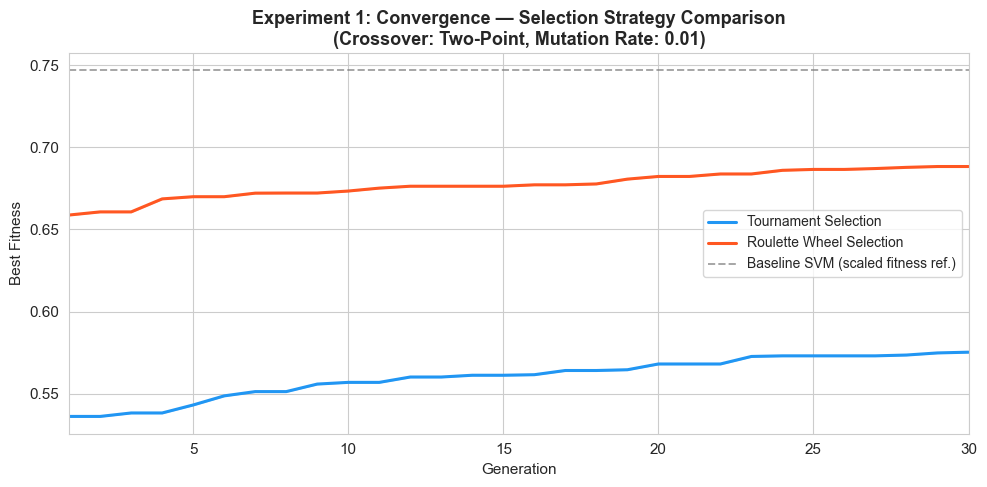

Figure saved → figures/exp1_convergence.png


In [ ]:
# ============================================================
# Cell 21: Experiment 1 — Convergence plot.
# Best fitness per generation (mean ± std band) for each
# selection strategy.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

colors_exp1  = {'tournament': '#2196F3', 'roulette': '#FF5722'}
labels_exp1  = {'tournament': 'Tournament Selection', 'roulette': 'Roulette Wheel Selection'}

for sel_name, histories in exp1_histories.items():
    arr  = np.array(histories)          # shape: (n_runs, n_generations)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    gens = np.arange(1, len(mean) + 1)

    ax.plot(gens, mean, label=labels_exp1[sel_name],
            color=colors_exp1[sel_name], linewidth=2.2)
    ax.fill_between(gens, mean - std, mean + std,
                    alpha=0.20, color=colors_exp1[sel_name])

ax.axhline(y=baseline_accuracy * ALPHA, color='gray', linestyle='--',
           linewidth=1.4, label='Baseline SVM (scaled fitness ref.)', alpha=0.7)

ax.set_title('Experiment 1: Convergence — Selection Strategy Comparison\n'
             f'(Crossover: Two-Point, Mutation Rate: {EXP1_MUT_RATE})', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, EXP1_GENERATIONS)
plt.tight_layout()
plt.savefig('figures/exp1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/exp1_convergence.png")

---
<a id='section6'></a>
## 6. Experiment 2 — Crossover & Selection Interaction

**Goal:** Examine how Uniform Crossover interacts with selection strategies.  
**Fixed:** Uniform Crossover, mutation_rate = 0.01, population_size = 30, n_generations = 30.  
**Runs:** 2 independent runs per selection strategy (Tournament vs Roulette).  
**Comparison:** Results vs Experiment 1 (Two-Point Crossover) reveal crossover impact.

In [ ]:
# ============================================================
# Cell 22: Experiment 2 — Run 1 → Uniform Crossover + Tournament.
# ============================================================

EXP2_CROSSOVER   = 'uniform'
EXP2_MUT_RATE    = 0.01
EXP2_POP_SIZE    = 30
EXP2_GENERATIONS = 30
EXP2_N_RUNS      = 2
EXP2_SELECTIONS  = ['tournament', 'roulette']

exp2_results  = {sel: [] for sel in EXP2_SELECTIONS}
exp2_histories = {sel: [] for sel in EXP2_SELECTIONS}

sel = 'tournament'
print(f"\n{'='*55}")
print(f" Experiment 2 | Uniform XO + {sel.upper()} | Run 1/{EXP2_N_RUNS}")
print(f"{'='*55}")

np.random.seed(RANDOM_SEED + 20)
best_ind, hist, cv_acc, n_feat = run_ga(
    population_size  = EXP2_POP_SIZE,
    n_generations    = EXP2_GENERATIONS,
    selection_method = sel,
    crossover_method = EXP2_CROSSOVER,
    mutation_rate    = EXP2_MUT_RATE,
    verbose          = True,
)
test_acc, n_sel, red_pct = evaluate_on_test(best_ind, X_train, y_train, X_test, y_test)
best_fit = hist[-1]

exp2_results[sel].append({'best_fitness': best_fit, 'test_accuracy': test_acc,
                           'n_features': n_sel, 'reduction_pct': red_pct,
                           'best_individual': best_ind})
exp2_histories[sel].append(hist)
print(f"\n  → Test Accuracy: {test_acc:.4f} | Features: {n_sel} | Reduction: {red_pct:.1f}%")


 Experiment 2 | Uniform XO + TOURNAMENT | Run 1/2
  Gen   Best Fitness   CV Accuracy    Features   Reduction
----------------------------------------------------------
    1         0.6432       0.7481      1458       69.9%
    6         0.6713       0.7814      1550       68.0%
   11         0.6836       0.7969      1626       66.4%
   16         0.6905       0.8054      1667       65.6%
   21         0.6946       0.8108      1702       64.9%
   26         0.6973       0.8152      1764       63.6%
   30         0.6979       0.8163      1778       63.3%

  GA Complete
  Best Fitness  : 0.6979
  CV Accuracy   : 0.8163  (81.63%)
  Features sel. : 1778 / 4844  (reduction: 63.3%)

  → Test Accuracy: 0.8173 | Features: 1778 | Reduction: 63.3%


In [ ]:
# ============================================================
# Cell 24: Experiment 2 — Run 1 → Uniform Crossover + Roulette.
# ============================================================

sel = 'roulette'
print(f"\n{'='*55}")
print(f" Experiment 2 | Uniform XO + {sel.upper()} | Run 1/{EXP2_N_RUNS}")
print(f"{'='*55}")

np.random.seed(RANDOM_SEED + 30)
best_ind, hist, cv_acc, n_feat = run_ga(
    population_size  = EXP2_POP_SIZE,
    n_generations    = EXP2_GENERATIONS,
    selection_method = sel,
    crossover_method = EXP2_CROSSOVER,
    mutation_rate    = EXP2_MUT_RATE,
    verbose          = True,
)
test_acc, n_sel, red_pct = evaluate_on_test(best_ind, X_train, y_train, X_test, y_test)
best_fit = hist[-1]

exp2_results[sel].append({'best_fitness': best_fit, 'test_accuracy': test_acc,
                           'n_features': n_sel, 'reduction_pct': red_pct,
                           'best_individual': best_ind})
exp2_histories[sel].append(hist)
print(f"\n  → Test Accuracy: {test_acc:.4f} | Features: {n_sel} | Reduction: {red_pct:.1f}%")


 Experiment 2 | Uniform XO + ROULETTE | Run 1/2
  Gen   Best Fitness   CV Accuracy    Features   Reduction
----------------------------------------------------------
    1         0.6743       0.7825      1449       70.1%
    6         0.6743       0.7825      1449       70.1%
   11         0.6777       0.7879      1520       68.6%
   16         0.6869       0.7997      1593       67.1%
   21         0.6886       0.8031      1656       65.8%
   26         0.6920       0.8075      1685       65.2%
   30         0.6929       0.8093      1716       64.6%

  GA Complete
  Best Fitness  : 0.6929
  CV Accuracy   : 0.8093  (80.93%)
  Features sel. : 1716 / 4844  (reduction: 64.6%)

  → Test Accuracy: 0.7998 | Features: 1716 | Reduction: 64.6%



Experiment 2 — Summary (mean ± std across 2 runs)
  [  tournament]  Test Acc: 0.8173 ± 0.0000  |  Features: 1778  |  Reduction: 63.3%  |  Fitness: 0.6979
  [    roulette]  Test Acc: 0.7998 ± 0.0000  |  Features: 1716  |  Reduction: 64.6%  |  Fitness: 0.6929


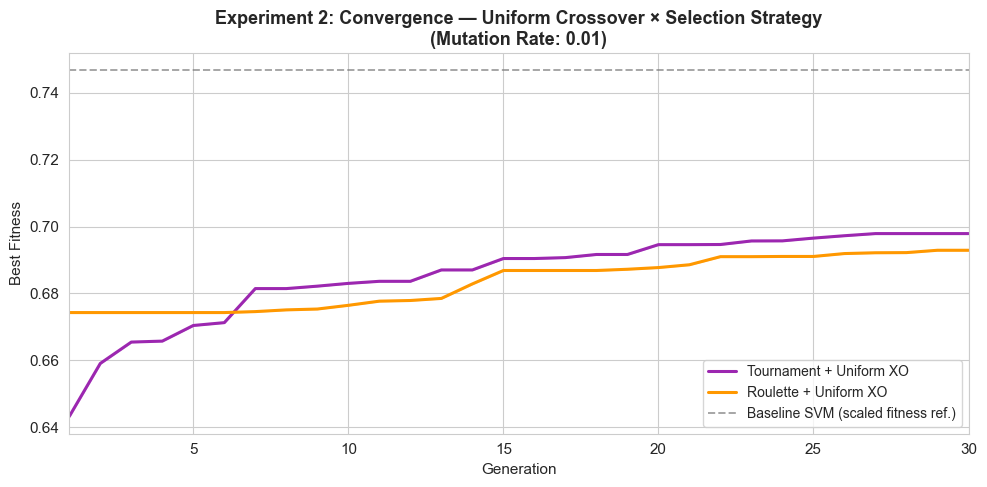

Figure saved → figures/exp2_convergence.png


In [ ]:
# ============================================================
# Cell 26: Experiment 2 — Summary table + convergence plot.
# ============================================================

exp2_summary = summarise_results(exp2_results, 'Exp2-Uniform-XO')

print("\nExperiment 2 — Summary (mean ± std across 2 runs)")
print("=" * 65)
for _, row in exp2_summary.iterrows():
    print(f"  [{row['Config']:>12}]  "
          f"Test Acc: {row['Avg Test Acc']:.4f} ± {row['Std Test Acc']:.4f}  |  "
          f"Features: {row['Avg Features']:.0f}  |  "
          f"Reduction: {row['Avg Reduction %']:.1f}%  |  "
          f"Fitness: {row['Avg Fitness']:.4f}")
print("=" * 65)

# Convergence plot
fig, ax = plt.subplots(figsize=(10, 5))

colors_exp2 = {'tournament': '#9C27B0', 'roulette': '#FF9800'}
labels_exp2 = {'tournament': 'Tournament + Uniform XO', 'roulette': 'Roulette + Uniform XO'}

for sel_name, histories in exp2_histories.items():
    arr  = np.array(histories)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    gens = np.arange(1, len(mean) + 1)
    ax.plot(gens, mean, label=labels_exp2[sel_name],
            color=colors_exp2[sel_name], linewidth=2.2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.20, color=colors_exp2[sel_name])

ax.axhline(y=baseline_accuracy * ALPHA, color='gray', linestyle='--',
           linewidth=1.4, label='Baseline SVM (scaled fitness ref.)', alpha=0.7)

ax.set_title('Experiment 2: Convergence — Uniform Crossover × Selection Strategy\n'
             f'(Mutation Rate: {EXP2_MUT_RATE})', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, EXP2_GENERATIONS)
plt.tight_layout()
plt.savefig('figures/exp2_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/exp2_convergence.png")

---
<a id='section8'></a>
## 8. Results Summary & Visualizations

In [ ]:
# ============================================================
# Cell 29: Build the master results DataFrame combining all
# experiments.  Formats and displays a styled summary table.
# ============================================================

# ── Combine all experiment summaries ────────────────────────
exp1_df = exp1_summary.copy()
exp1_df['Config'] = 'E1-' + exp1_df['Config'] + ' (2pt-XO)'

exp2_df = exp2_summary.copy()
exp2_df['Config'] = 'E2-' + exp2_df['Config'] + ' (Uni-XO)'


all_results_df = pd.concat([exp1_df, exp2_df], ignore_index=True)

# ── Prettify column names ───────────────────────────────────
display_cols = {
    'Config'          : 'Configuration',
    'Avg Test Acc'    : 'Avg Test Acc',
    'Std Test Acc'    : 'Std',
    'Avg Features'    : 'Avg Features',
    'Avg Reduction %' : 'Avg Reduction %',
    'Avg Fitness'     : 'Avg Fitness',
}
table_df = all_results_df[list(display_cols.keys())].rename(columns=display_cols)

# Add baseline row
baseline_row = pd.DataFrame([{
    'Configuration' : 'BASELINE SVM (all features)',
    'Avg Test Acc'  : baseline_accuracy,
    'Std'           : 0.0,
    'Avg Features'  : N_FEATURES,
    'Avg Reduction %': 0.0,
    'Avg Fitness'   : float('nan'),
}])
table_df = pd.concat([baseline_row, table_df], ignore_index=True)

# Format floats
for col in ['Avg Test Acc', 'Std', 'Avg Fitness']:
    table_df[col] = table_df[col].apply(lambda x: f"{x:.4f}" if not pd.isna(x) else 'N/A')
table_df['Avg Features']    = table_df['Avg Features'].apply(lambda x: f"{x:.0f}")
table_df['Avg Reduction %'] = table_df['Avg Reduction %'].apply(lambda x: f"{x:.1f}%")

print("\n" + "=" * 80)
print("MASTER SUMMARY TABLE — All Configurations")
print("=" * 80)
print(table_df.to_string(index=False))
print("=" * 80)


MASTER SUMMARY TABLE — All Configurations
              Configuration Avg Test Acc    Std Avg Features Avg Reduction % Avg Fitness
BASELINE SVM (all features)       0.8297 0.0000         4844            0.0%         N/A
     E1-tournament (2pt-XO)       0.8132 0.0000         1758           63.7%      0.5753
       E1-roulette (2pt-XO)       0.8111 0.0000         1751           63.9%      0.6883
     E2-tournament (Uni-XO)       0.8173 0.0000         1778           63.3%      0.6979
       E2-roulette (Uni-XO)       0.7998 0.0000         1716           64.6%      0.6929


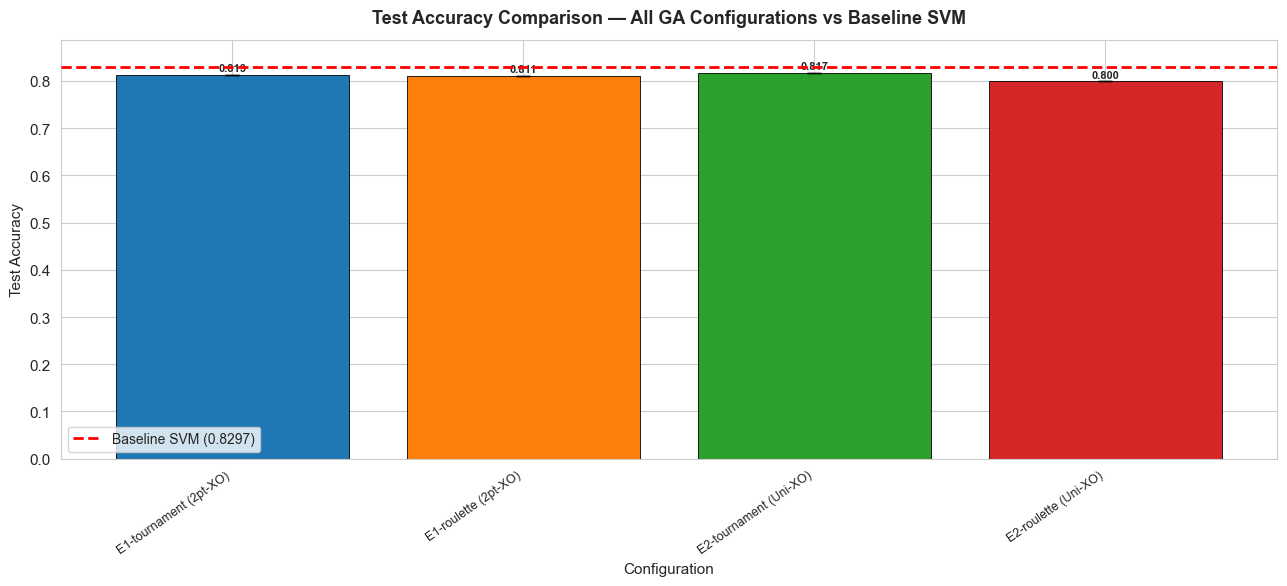

Figure saved → figures/accuracy_comparison.png


In [ ]:
# ============================================================
# Cell 30: Bar chart — Test accuracy comparison across all
# GA configurations (with error bars) vs baseline.
# ============================================================

# Re-extract numeric data for plotting
plot_configs   = all_results_df['Config'].tolist()
plot_acc_mean  = all_results_df['Avg Test Acc'].tolist()
plot_acc_std   = all_results_df['Std Test Acc'].tolist()

fig, ax = plt.subplots(figsize=(13, 6))

x      = np.arange(len(plot_configs))
colors = sns.color_palette('tab10', len(plot_configs))

bars = ax.bar(x, plot_acc_mean, yerr=plot_acc_std,
              color=colors, edgecolor='black', linewidth=0.6,
              capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

# Baseline reference line
ax.axhline(y=baseline_accuracy, color='red', linestyle='--',
           linewidth=2, label=f'Baseline SVM ({baseline_accuracy:.4f})', zorder=5)

# Annotate bar values
for bar, mean_val in zip(bars, plot_acc_mean):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(plot_acc_std) + 0.003,
            f'{mean_val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(plot_configs, rotation=35, ha='right', fontsize=9)
ax.set_title('Test Accuracy Comparison — All GA Configurations vs Baseline SVM',
             fontweight='bold', pad=12)
ax.set_xlabel('Configuration')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, min(1.05, max(plot_acc_mean) + 0.07))
ax.legend()
plt.tight_layout()
plt.savefig('figures/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/accuracy_comparison.png")

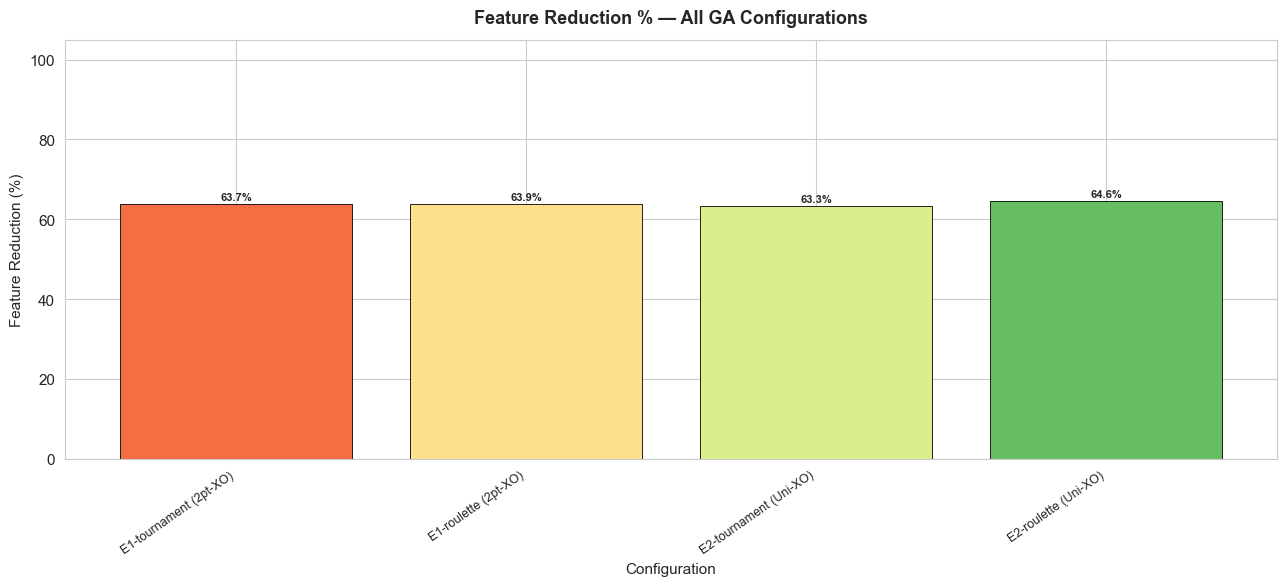

Figure saved → figures/feature_reduction.png


In [ ]:
# ============================================================
# Cell 31: Bar chart — Feature reduction % across all configs.
# ============================================================

plot_reductions = all_results_df['Avg Reduction %'].tolist()

fig, ax = plt.subplots(figsize=(13, 6))

colors_red = sns.color_palette('RdYlGn', len(plot_configs))
bars_red   = ax.bar(x, plot_reductions, color=colors_red,
                    edgecolor='black', linewidth=0.6)

for bar, red_val in zip(bars_red, plot_reductions):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{red_val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(plot_configs, rotation=35, ha='right', fontsize=9)
ax.set_title('Feature Reduction % — All GA Configurations',
             fontweight='bold', pad=12)
ax.set_xlabel('Configuration')
ax.set_ylabel('Feature Reduction (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('figures/feature_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/feature_reduction.png")

Best GA Configuration : E2-tournament (Uni-XO)
  Avg Test Accuracy   : 0.8173
  Avg Features Used   : 1778 / 4844
  Feature Reduction   : 63.3%


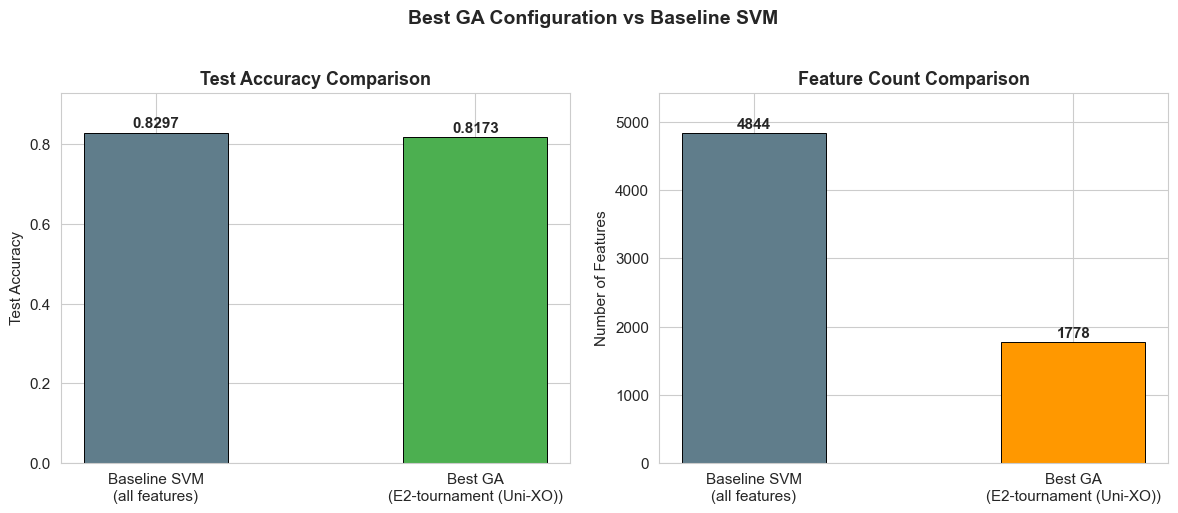

Figure saved → figures/best_ga_vs_baseline.png


In [ ]:
# ============================================================
# Cell 32: Find the single best GA configuration overall.
# Side-by-side bar chart: Best GA vs Baseline SVM.
# ============================================================

# Identify the best GA config (highest average test accuracy)
best_ga_idx      = all_results_df['Avg Test Acc'].idxmax()
best_ga_config   = all_results_df.loc[best_ga_idx, 'Config']
best_ga_acc      = all_results_df.loc[best_ga_idx, 'Avg Test Acc']
best_ga_feats    = all_results_df.loc[best_ga_idx, 'Avg Features']
best_ga_exp      = all_results_df.loc[best_ga_idx, 'Experiment']

print(f"Best GA Configuration : {best_ga_config}")
print(f"  Avg Test Accuracy   : {best_ga_acc:.4f}")
print(f"  Avg Features Used   : {best_ga_feats:.0f} / {N_FEATURES}")
print(f"  Feature Reduction   : {(1 - best_ga_feats/N_FEATURES)*100:.1f}%")

# ── Side-by-side bar chart: Accuracy & Feature Count ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Accuracy
acc_vals   = [baseline_accuracy, best_ga_acc]
acc_labels = ['Baseline SVM\n(all features)', f'Best GA\n({best_ga_config})']
acc_colors = ['#607D8B', '#4CAF50']

bars_acc = axes[0].bar(acc_labels, acc_vals, color=acc_colors,
                       edgecolor='black', linewidth=0.7, width=0.45)
for bar, val in zip(bars_acc, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0, min(1.1, max(acc_vals) * 1.12))

# Subplot 2: Feature count
feat_vals   = [N_FEATURES, best_ga_feats]
feat_labels = ['Baseline SVM\n(all features)', f'Best GA\n({best_ga_config})']
feat_colors = ['#607D8B', '#FF9800']

bars_feat = axes[1].bar(feat_labels, feat_vals, color=feat_colors,
                        edgecolor='black', linewidth=0.7, width=0.45)
for bar, val in zip(bars_feat, feat_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Feature Count Comparison', fontweight='bold')
axes[1].set_ylabel('Number of Features')
axes[1].set_ylim(0, N_FEATURES * 1.12)

fig.suptitle('Best GA Configuration vs Baseline SVM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/best_ga_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/best_ga_vs_baseline.png")

Best single run: E2-tournament-uniform-run1  (final fitness = 0.6979)


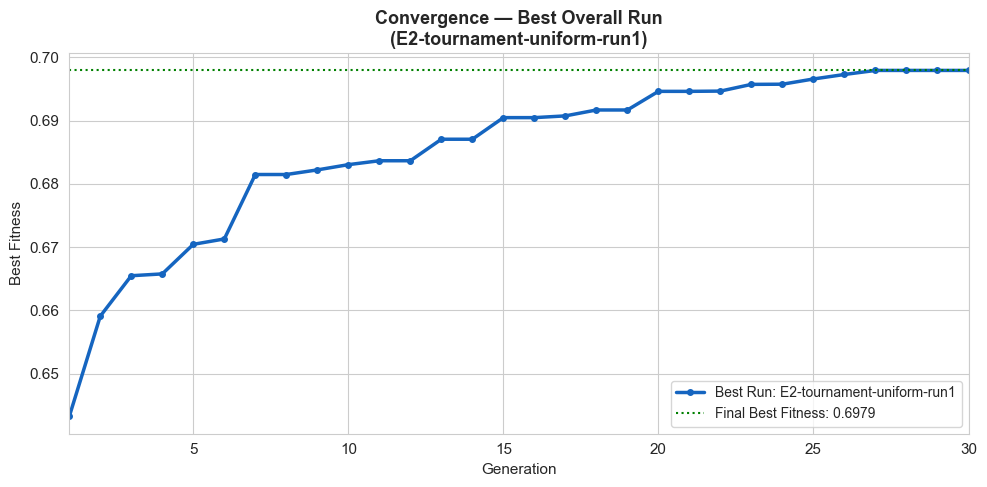

Figure saved → figures/best_run_convergence.png


In [ ]:
# ============================================================
# Cell 33: Convergence plot of the single best run found
# across ALL experiments.
# ============================================================

# Collect all individual runs and their final best fitness
all_runs = []

for sel, runs in exp1_results.items():
    for i, r in enumerate(runs):
        all_runs.append({
            'label'  : f'E1-{sel}-run{i+1}',
            'history': exp1_histories[sel][i],
            'fitness': r['best_fitness'],
        })

for sel, runs in exp2_results.items():
    for i, r in enumerate(runs):
        all_runs.append({
            'label'  : f'E2-{sel}-uniform-run{i+1}',
            'history': exp2_histories[sel][i],
            'fitness': r['best_fitness'],
        })


# Find the absolute best run
best_run    = max(all_runs, key=lambda r: r['fitness'])
best_hist   = best_run['history']
best_label  = best_run['label']
best_fit_v  = best_run['fitness']

print(f"Best single run: {best_label}  (final fitness = {best_fit_v:.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
gens = np.arange(1, len(best_hist) + 1)
ax.plot(gens, best_hist, color='#1565C0', linewidth=2.5, marker='o',
        markersize=4, label=f'Best Run: {best_label}')
ax.axhline(y=best_fit_v, color='green', linestyle=':', linewidth=1.5,
           label=f'Final Best Fitness: {best_fit_v:.4f}')
ax.set_title(f'Convergence — Best Overall Run\n({best_label})', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()
ax.set_xlim(1, len(best_hist))
plt.tight_layout()
plt.savefig('figures/best_run_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/best_run_convergence.png")

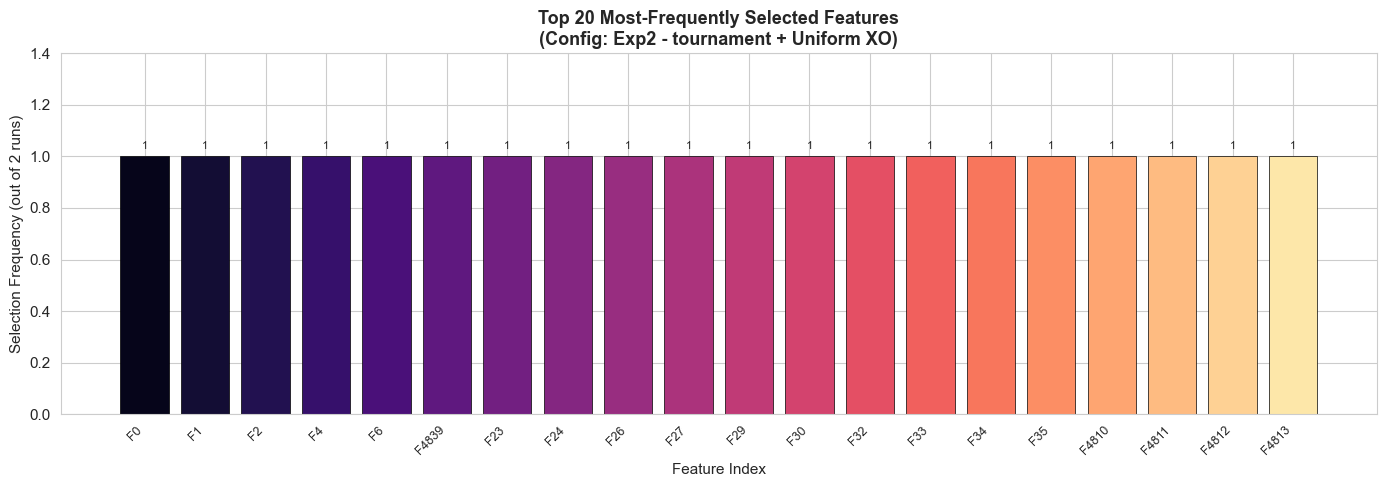

Figure saved → figures/top20_features.png

Top 20 feature indices: [0, 1, 2, 4, 6, 4839, 23, 24, 26, 27, 29, 30, 32, 33, 34, 35, 4810, 4811, 4812, 4813]


In [ ]:
# ============================================================
# Cell 34: Feature selection frequency — top 20 most commonly
# selected features across all runs of the best GA config.
# ============================================================

# Identify which experiment the best config belongs to
# and collect ALL individual binary masks from that config
best_run_label = best_run['label']

if best_run_label.startswith('E1'):
    best_sel_key = 'tournament' if 'tournament' in best_run_label else 'roulette'
    best_masks   = [r['best_individual'] for r in exp1_results[best_sel_key]]
    config_desc  = f'Exp1 - {best_sel_key} + Two-Point XO'
elif best_run_label.startswith('E2'):
    best_sel_key = 'tournament' if 'tournament' in best_run_label else 'roulette'
    best_masks   = [r['best_individual'] for r in exp2_results[best_sel_key]]
    config_desc  = f'Exp2 - {best_sel_key} + Uniform XO'
else:  # E3
    mut_key = best_run_label.split('mut')[1].split('-')[0]
    best_masks  = [r['best_individual'] for r in exp3_results[mut_key]]
    config_desc = f'Exp3 - mutation_rate={mut_key}'

# Compute selection frequency per feature
freq = np.sum(best_masks, axis=0)  # shape: (n_features,)
top20_idx   = np.argsort(freq)[-20:][::-1]
top20_freq  = freq[top20_idx]
top20_labels = [f'F{i}' for i in top20_idx]

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('magma', 20)
bars_f = ax.bar(np.arange(20), top20_freq, color=palette, edgecolor='black', linewidth=0.5)

for bar, f in zip(bars_f, top20_freq):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            str(int(f)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(np.arange(20))
ax.set_xticklabels(top20_labels, rotation=45, ha='right', fontsize=9)
ax.set_title(f'Top 20 Most-Frequently Selected Features\n(Config: {config_desc})',
             fontweight='bold')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Selection Frequency (out of 2 runs)')
ax.set_ylim(0, max(top20_freq) + 0.4)
plt.tight_layout()
plt.savefig('figures/top20_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/top20_features.png")
print(f"\nTop 20 feature indices: {top20_idx.tolist()}")

In [ ]:
# ============================================================
# Cell 35: Save all experiment results to final_results.csv.
# ============================================================

# Build full numeric results table (without display formatting)
csv_rows = []

csv_rows.append({
    'Experiment'     : 'Baseline',
    'Config'         : 'SVM_all_features',
    'Run'            : 1,
    'Best Fitness'   : float('nan'),
    'Test Accuracy'  : baseline_accuracy,
    'N Features'     : N_FEATURES,
    'Reduction Pct'  : 0.0,
    'Baseline F1'    : baseline_f1,
})

for sel, runs in exp1_results.items():
    for run_i, r in enumerate(runs):
        csv_rows.append({
            'Experiment'   : 'Exp1-Selection',
            'Config'       : sel,
            'Run'          : run_i + 1,
            'Best Fitness' : r['best_fitness'],
            'Test Accuracy': r['test_accuracy'],
            'N Features'   : r['n_features'],
            'Reduction Pct': r['reduction_pct'],
            'Baseline F1'  : baseline_f1,
        })

for sel, runs in exp2_results.items():
    for run_i, r in enumerate(runs):
        csv_rows.append({
            'Experiment'   : 'Exp2-UniformXO',
            'Config'       : sel,
            'Run'          : run_i + 1,
            'Best Fitness' : r['best_fitness'],
            'Test Accuracy': r['test_accuracy'],
            'N Features'   : r['n_features'],
            'Reduction Pct': r['reduction_pct'],
            'Baseline F1'  : baseline_f1,
        })



final_csv = pd.DataFrame(csv_rows)
final_csv.to_csv('final_results.csv', index=False)

print("Results saved : final_results.csv")
print(f"   Shape: {final_csv.shape}")
print("\nPreview:")
print(final_csv.to_string(index=False))

Results saved : final_results.csv
   Shape: (5, 8)

Preview:
    Experiment           Config  Run  Best Fitness  Test Accuracy  N Features  Reduction Pct  Baseline F1
      Baseline SVM_all_features    1           NaN       0.829721        4844       0.000000     0.828216
Exp1-Selection       tournament    1      0.575261       0.813209        1758      63.707680     0.828216
Exp1-Selection         roulette    1      0.688266       0.811146        1751      63.852188     0.828216
Exp2-UniformXO       tournament    1      0.697927       0.817337        1778      63.294798     0.828216
Exp2-UniformXO         roulette    1      0.692937       0.799794        1716      64.574732     0.828216
